Raw shape: (32581, 12)


C:\Users\TSB\AppData\Local\Temp\ipykernel_11988\834084736.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\TSB\AppData\Local\Temp\ipykernel_11988\834084736.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using

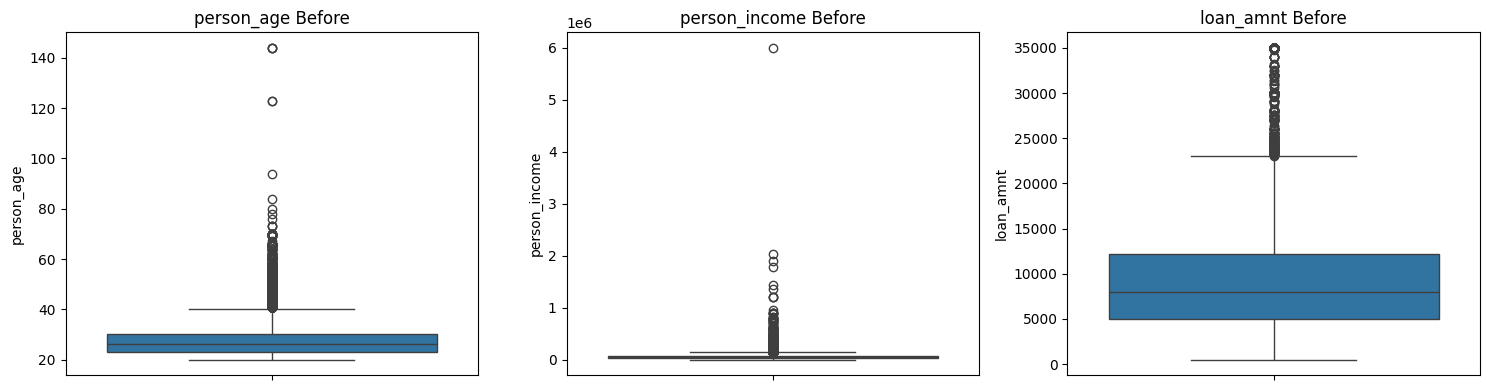

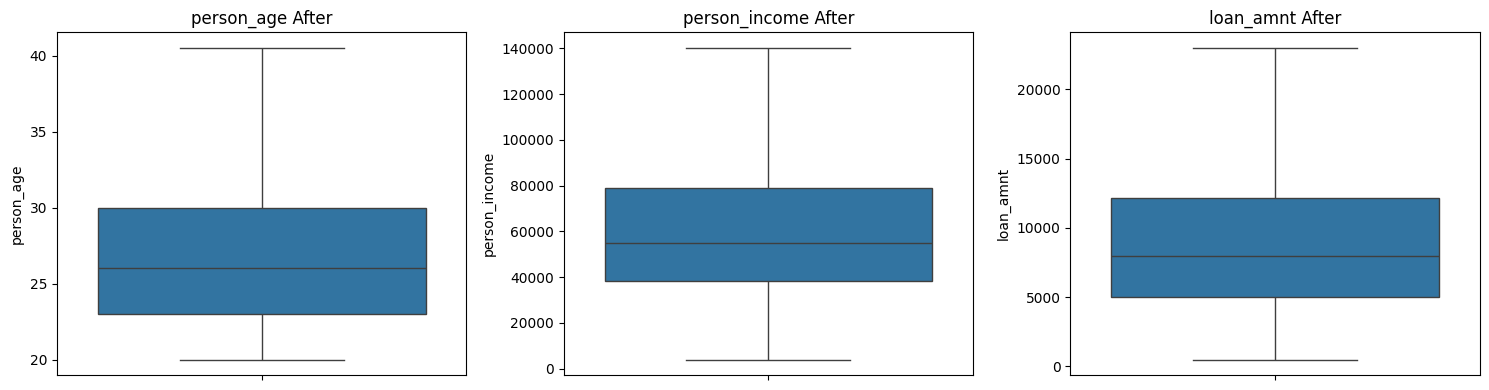

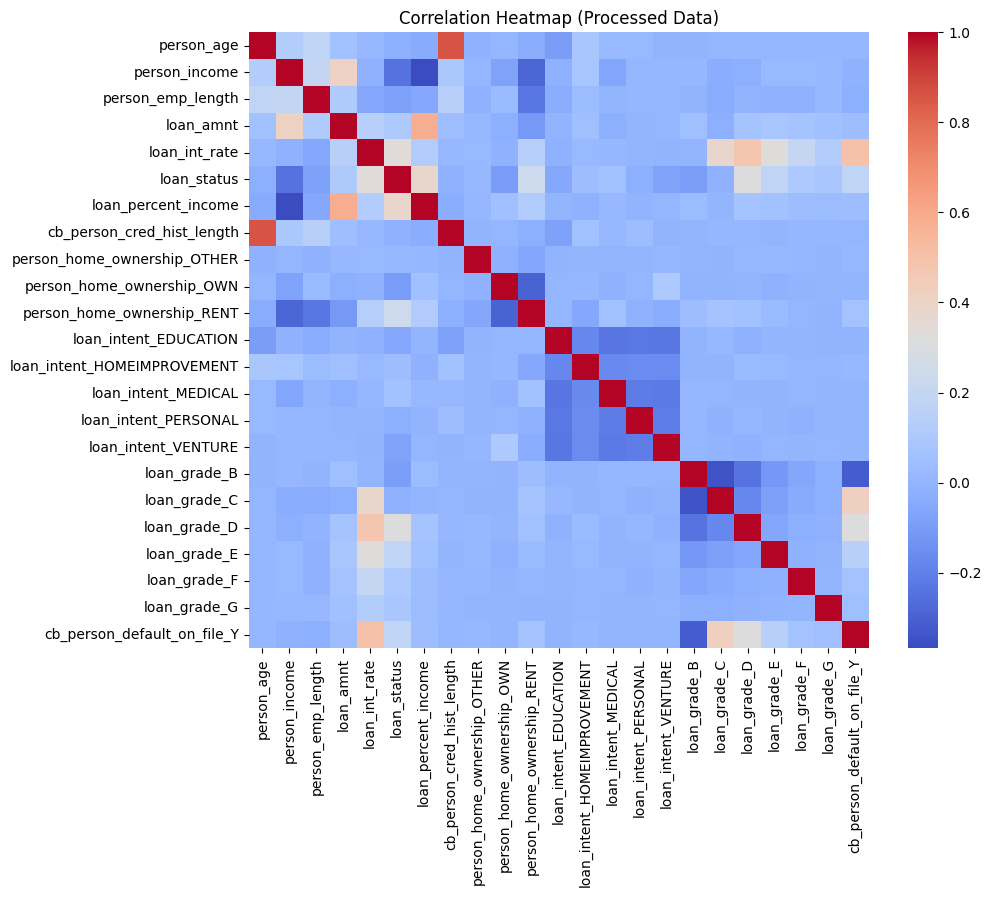

Preprocessing complete


In [1]:
# =========================================
# 02 — PREPROCESSING
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# LOAD DATA
df = pd.read_csv('../data/raw/raw_data.csv')
print("Raw shape:", df.shape)

# ================================
# HANDLE MISSING VALUES
# ================================
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ================================
# BOXPLOTS BEFORE OUTLIERS
# ================================
cols = ['person_age', 'person_income', 'loan_amnt']

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"{col} Before")

plt.tight_layout()
plt.savefig('../plots/boxplots_before_outlier_handling.png')
plt.show()

# ================================
# OUTLIER HANDLING (IQR)
# ================================
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# ================================
# BOXPLOTS AFTER OUTLIERS
# ================================
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"{col} After")

plt.tight_layout()
plt.savefig('../plots/boxplots_after_outlier_capping.png')
plt.show()

# ================================
# ENCODING
# ================================
df = pd.get_dummies(df, drop_first=True)

# ================================
# SCALING
# ================================
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# ================================
# CORRELATION HEATMAP (PROCESSED)
# ================================
plt.figure(figsize=(10,8))
sns.heatmap(df_scaled.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Processed Data)")
plt.savefig('../plots/correlation_heatmap_processed_data.png')
plt.show()

# ================================
# SAVE DATA
# ================================
df_scaled.to_csv('../data/processed/processed_data.csv', index=False)

print("Preprocessing complete")